# Plot results for offline prompting in the "farm" example

In [1]:
%cd ..
%pwd  # should be "llm-adaptation"

C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation


'C:\\Users\\micha\\OneDrive - Univerzita Karlova\\research\\2024-LLM-DEECo\\llm-adaptation'

In [2]:
from pathlib import Path
import pandas as pd
import shutil
import subprocess
import sys
import json
import matplotlib.pyplot as plt
from matplotlib.markers import MarkerStyle
import numpy as np

In [3]:
results_folder = Path("generated_adaptations/farm")
pd.options.display.float_format = "{:,.1f}".format

## Run experiments

In [4]:
prompts = {
    "default": "generated_adaptations/prompts_user/farm_strategy.md",
    "state": "generated_adaptations/prompts_user/farm_strategy_state.md",
}
variants = {
    "system": "system",
    "constraints": "all",
    "stats": "stats",
    "result": "result",
}
llms = {
    # "5nanolow": "gpt-5-nano-2025-08-07,reasoning_effort=low",
    "5nano": "gpt-5-nano-2025-08-07",
    # "5mini": "gpt-5-mini-2025-08-07",
    # "5": "gpt-5-2025-08-07",
}
repeats = 1
start = 1

In [5]:
# import generated_adaptations.generator as generator

In [19]:
for prompt_name, prompt in prompts.items():
    for variant, mode in variants.items():
        for llm_name, llm in llms.items():
            for repeat in range(start, start + repeats):
                folder_name = f"{llm_name}_{repeat:02d}"
                print(f"\n{variant}_{prompt_name}/{folder_name}\n")
                folder = results_folder / f"{variant}_{prompt_name}" / folder_name
                folder.mkdir(parents=True, exist_ok=True)
                shutil.copy(prompt, folder / "01_user.md")
                cmd  = [sys.executable, "generated_adaptations/generator.py", f"--folder={str(folder)}", f"--llm={llm}", f"--mode={mode}"]
                result = subprocess.run(cmd, capture_output=True, text=True)  # even capture_output=False does not stream in real-time, so we rather capture it and print it later
                print(result.stdout)
                print(result.stderr)
                # generator.main([f"--folder={str(folder)}"])  # this also does not show the real-time output


system_default/5nano_01

Loaded 2 messages from generated_adaptations\farm\system_default\5nano_01.
Querying LLM with prompt 01_user.
TOKENS USED:
Input: 1010, Output: 4403 (reasoning: 3008)
Response time (seconds): 30.7

LLM response saved to '02_llm.md'.
Code block saved to 'generated_adaptations\farm\system_default\5nano_01\code_02.py'.
Running tests (system): pytest generated_adaptations/tests -q --tb=short -rfExXpP --show-capture=no --color=no --example=farm --adaptation_name=5nano_01/code_02 --variant=system_default --tests=system
Test exit code: 0
Running tests (all): pytest generated_adaptations/tests -q --tb=short -rfExXpP --show-capture=no --color=no --example=farm --adaptation_name=5nano_01/code_02 --variant=system_default --tests=all
Test exit code: 1
Running simulation for 'generated_adaptations\farm\system_default\5nano_01\code_02.py'.
  Run #1/3: python main.py farm/configs/default.yaml generated_adaptations/configs/generated.yaml farm/configs/config_no_battery.yaml DSL

## Results

In [25]:
folders = list(results_folder.glob("*/*"))
# folders = list(results_folder.glob("41mini_*"))
# folders = list(results_folder.glob("*/5nanolow*"))
# folders = [results_folder / "41mini"]

folders = [f for f in folders if "mock" not in f.parent.stem]
print([(f.parent.stem, f.stem) for f in folders])

[('constraints_default', '5nano_01'), ('constraints_state', '5nano_01'), ('result_default', '5nano_01'), ('result_state', '5nano_01'), ('stats_default', '5nano_01'), ('stats_state', '5nano_01'), ('system_default', '5nano_01'), ('system_state', '5nano_01')]


In [26]:
summary = pd.DataFrame(columns=["llm", "params", "repeat"])

for folder in folders:
    llm, repeat = folder.stem.split("_")
    params = folder.parent.stem
    summary.loc[len(summary), ["llm", "params", "repeat"]] = [llm, params, repeat]

    for file in (folder / "results").glob("*.txt"):
        name = file.stem.removeprefix("code_")
        code = name.split("_")[0]
        if "_missing" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "missing"
        if "_system_fail" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "fail"
        elif "_system_pass" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "pass"
        elif "_all_fail" in name:
            summary.loc[len(summary) - 1, code + "_user"] = "fail"
        elif "_all_pass" in name:
            summary.loc[len(summary) - 1, code + "_user"] = "pass"
        else:
            print(f"Unknown file: {file}")
    for file in (folder / "results").glob("*.json"):
        name = file.stem.removeprefix("code_")
        if "_simulation_result" in name:
            code = name.removesuffix("_simulation_result")
            results = json.load(open(file))
            result = results["damage"]
            summary.loc[len(summary) - 1, code + "_result"] = result
        else:
            print(f"Unknown file: {file}")
summary.fillna("", inplace=True)

Unknown file: generated_adaptations\farm\stats_state\5nano_01\results\code_04_missing.txt


C:\Users\micha\AppData\Local\Temp\ipykernel_36940\1073944023.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary.fillna("", inplace=True)


In [27]:
summary.set_index(["llm", "params", "repeat"], inplace=True)

In [28]:
summary = summary.reindex(sorted(summary.columns), axis=1)

In [29]:
summary

02_result 02_system 02_user 04_result  \
llm   params              repeat                                          
5nano constraints_default 01           52.0      pass    fail             
      constraints_state   01          123.3      fail    fail     285.3   
      result_default      01          123.3      pass    fail      55.0   
      result_state        01          123.3      pass    fail      52.3   
      stats_default       01          169.3      fail    fail     281.0   
      stats_state         01          118.0      fail    fail             
      system_default      01          138.7      pass    fail     129.0   
      system_state        01          123.0      pass    fail      66.3   

                                 04_system 04_user 06_result 06_system  \
llm   params              repeat                                         
5nano constraints_default 01                                             
      constraints_state   01          pass    fail     285.3      pass   
      result_default      01          pass    pass                       
      result_state        01          fail    fail                       
      stats_default       01          fail    fail     148.3      fail   
      stats_state         01       missing              49.3      fail   
      system_default      01          pass    pass     129.0      pass   
      system_state        01          pass    pass      66.3      pass   

                                 06_user 08_result  ... 14_user 16_result  \
llm   params              repeat                    ...                     
5nano constraints_default 01                        ...                     
      constraints_state   01        fail     285.3  ...    pass     294.3   
      result_default      01                        ...                     
      result_state        01                        ...                     
      stats_default       01        fail     287.3  ...    fail     216.3   
      stats_state         01        fail            ...                     
      system_default      01        pass      52.3  ...                     
      system_state        01        pass      49.7  ...                     

                                 16_system 16_user 18_result 18_system  \
llm   params              repeat                                         
5nano constraints_default 01                                             
      constraints_state   01          pass    fail     285.3      pass   
      result_default      01                                             
      result_state        01                                             
      stats_default       01          fail    fail     286.0      fail   
      stats_state         01                                             
      system_default      01                                             
      system_state        01                                             

                                 18_user 20_result 20_system 20_user  
llm   params              repeat                                      
5nano constraints_default 01                                          
      constraints_state   01        fail     111.3      pass    pass  
      result_default      01                                          
      result_state        01                                          
      stats_default       01        fail     168.7      fail    fail  
      stats_state         01                                          
      system_default      01                                          
      system_state        01                                          

[8 rows x 30 columns]

### Plot

In [30]:
colors = {
    "5nano/constraints": "tab:blue",
    "5nano/system": "tab:green",
    "5nano/result": "tab:orange",
    "5nano/stats": "tab:red",
}

In [32]:
result_cols = [col for col in summary.columns if col.endswith("_result")]
plot_data = summary[result_cols].replace({"": np.nan}).astype(float)
plot_data

C:\Users\micha\AppData\Local\Temp\ipykernel_36940\65529393.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_data = summary[result_cols].replace({"": np.nan}).astype(float)


02_result  04_result  06_result  08_result  \
llm   params              repeat                                               
5nano constraints_default 01           52.0        NaN        NaN        NaN   
      constraints_state   01          123.3      285.3      285.3      285.3   
      result_default      01          123.3       55.0        NaN        NaN   
      result_state        01          123.3       52.3        NaN        NaN   
      stats_default       01          169.3      281.0      148.3      287.3   
      stats_state         01          118.0        NaN       49.3        NaN   
      system_default      01          138.7      129.0      129.0       52.3   
      system_state        01          123.0       66.3       66.3       49.7   

                                  10_result  12_result  14_result  16_result  \
llm   params              repeat                                               
5nano constraints_default 01            NaN        NaN        NaN        NaN   
      constraints_state   01          285.3      111.3      111.3      294.3   
      result_default      01            NaN        NaN        NaN        NaN   
      result_state        01            NaN        NaN        NaN        NaN   
      stats_default       01          287.3      168.7      216.3      216.3   
      stats_state         01            NaN        NaN        NaN        NaN   
      system_default      01            NaN        NaN        NaN        NaN   
      system_state        01            NaN        NaN        NaN        NaN   

                                  18_result  20_result  
llm   params              repeat                        
5nano constraints_default 01            NaN        NaN  
      constraints_state   01          285.3      111.3  
      result_default      01            NaN        NaN  
      result_state        01            NaN        NaN  
      stats_default       01          286.0      168.7  
      stats_state         01            NaN        NaN  
      system_default      01            NaN        NaN  
      system_state        01            NaN        NaN

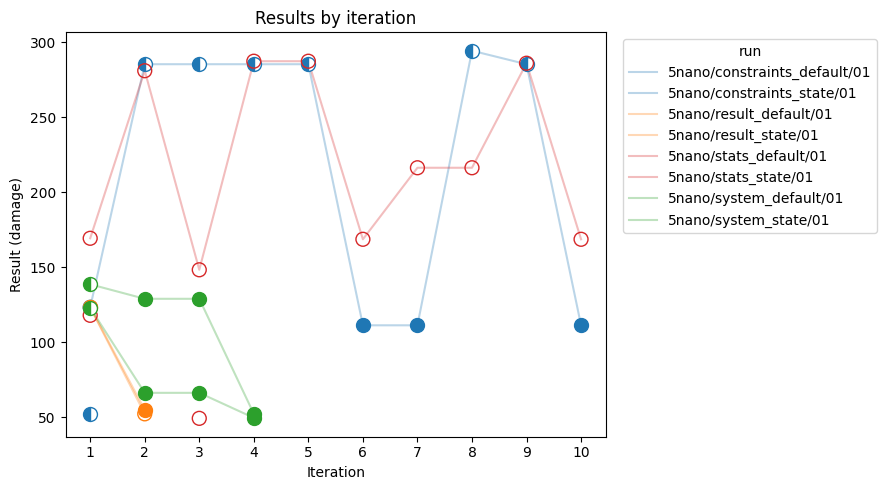

In [34]:
plot_df = plot_data.T.copy()  # index: result columns like `02_result`, columns: MultiIndex (llm, params, repeat)
orig_cols = plot_df.columns  # MultiIndex
labels = [f"{llm}/{params}/{repeat}" for llm, params, repeat in orig_cols]
x = list(range(1, len(plot_df.index) + 1))

fig, ax = plt.subplots(figsize=(9, 5))
for col, label in zip(orig_cols, labels):
    y = plot_df[col].values
    # draw the line for the run
    color = colors[label.rsplit("/", 1)[0].rsplit("_", 1)[0]]
    line, = ax.plot(x, y, '-', label=label, alpha=0.3, color=color)

    # collect indices by test status
    pass_idx, half_idx, fail_idx = [], [], []
    for i, result_col in enumerate(plot_df.index):  # e.g. '02_result'
        system_col = result_col.replace('_result', '_system')
        user_col = result_col.replace('_result', '_user')

        system = summary.loc[col, system_col]
        user = summary.loc[col, user_col]

        if system == "pass" and user == "pass":
            pass_idx.append(i)
        elif system == "pass":
            half_idx.append(i)
        else:
            fail_idx.append(i)

    # overplot markers (use same color as the line)
    scatter_kwargs = {
        "zorder": 3, "s": 100, "alpha": 1
    }
    if pass_idx:
        ax.scatter([x[i] for i in pass_idx], [y[i] for i in pass_idx], marker='o', color=color, **scatter_kwargs)
    if half_idx:
        ax.scatter([x[i] for i in half_idx], [y[i] for i in half_idx], marker=MarkerStyle("o", fillstyle="left"), color=color, **scatter_kwargs)
        ax.scatter([x[i] for i in half_idx], [y[i] for i in half_idx], marker=MarkerStyle("o", fillstyle="right"), color="white", edgecolors=color, **scatter_kwargs)
    if fail_idx:
        ax.scatter([x[i] for i in fail_idx], [y[i] for i in fail_idx], marker='o', color=color, facecolors='none', **scatter_kwargs)

# finalize axes
ax.set_xticks(x)
ax.set_xticklabels(x)  # iterations 1,2,3,...
ax.set_xlabel("Iteration")
ax.set_ylabel("Result (damage)")
ax.set_title("Results by iteration")
ax.legend(title="run", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Iterations counts

In [35]:
iterations = summary.apply(lambda row: sum(1 for col in result_cols if row[col] != ""), axis=1, )
iterations = pd.DataFrame(iterations).rename(columns={0: "iterations"})
iterations

iterations
llm   params              repeat            
5nano constraints_default 01               1
      constraints_state   01              10
      result_default      01               2
      result_state        01               2
      stats_default       01              10
      stats_state         01               2
      system_default      01               4
      system_state        01               4